In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/hapmap/hprc_truthset_eval/combined_tables/HPRC.vcfeval.by_sample.all.tsv", sep='\t')
df_long = pd.melt(df,
                  id_vars=['tool', 'tech', 'sample'],  # Columns to keep as identifier variables
                  var_name='Metric',   # Name for the new column holding the original column names
                  value_name='Value')
df_long 

,tool,tech,sample,Metric,Value
0,mitoscope,pacbio,hapmap-pacbio-bcm,true_positives_baseline,96.0000
1,mitoscope,pacbio,hapmap-pacbio-broad,true_positives_baseline,95.0000
2,mitoscope,pacbio,hapmap-pacbio-uwsc,true_positives_baseline,84.0000
3,mitoscope,pacbio,hapmap-pacbio-washu,true_positives_baseline,96.0000
4,mitoscope,ont,hapmap-ont-bcm,true_positives_baseline,83.0000
...,...,...,...,...,...
149,mitorsaw,pacbio,hapmap-pacbio-washu,f_measure,0.5562
150,mutect2,illumina,hapmap-illumina-bcm,f_measure,0.7273
151,mutect2,illumina,hapmap-illumina-broad,f_measure,0.6250
152,mutect2,illumina,hapmap-illumina-nygc,f_measure,0.5749


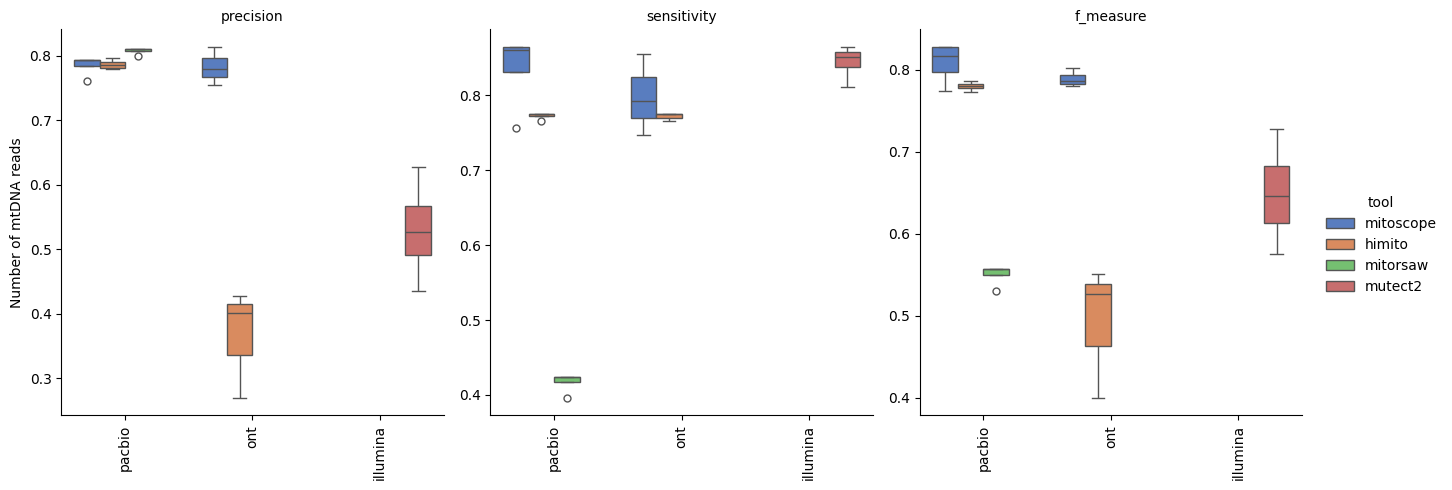

In [63]:
g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['precision', 'sensitivity', 'f_measure'])],
    x="tech",
    y="Value",
    col="Metric",
    #col_wrap=4,
    hue="tool",
    kind="box",
    height=5,
    aspect=0.8,
    palette="muted",
    #legend_out=False,
    sharex=False,
    sharey=False,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name}")
g.set_axis_labels("", "Number of mtDNA reads")
g.tick_params(axis='x', labelrotation=90)
#g.set(ylim=(0, 1))
plt.tight_layout()
#plt.xlim(0,1)
plt.show()

# sns.boxplot(data=df,x="tech", y="sensitivity", hue="tool", dodge=True)
# plt.ylim(0,1)

In [ ]:
## plot of mitoscope heteroplasmy levels vs mutect 2 heteroplasmy levels (correlation plot or heat map w R2 value?)
## i need to pull HPL fields from baldur vcf (table of variant and HPL val? dont i have this?)